In [ ]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential
from keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sb

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

과제
---------
sklearn 의 breast_cancer 데이터셋

1. train, test 나누기
2. 정규화
3. 케라스 학습
4. train, test 각각 confusion matrix(heat map 포함), f1, acc
5. 1번째행 예측값

In [3]:
bc = load_breast_cancer( as_frame=True)
df=bc['frame']
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [4]:
x_train,x_test,y_train,y_test=train_test_split(
    df.iloc[:,:-1],
    df.iloc[:,-1],
    test_size=0.2,
    stratify=df.iloc[:,-1],
    random_state=42
)

In [5]:
st=StandardScaler()
x_train=st.fit_transform(x_train)
x_test=st.transform(x_test)
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

In [6]:
dense=Dense(units=1,input_dim=30, activation='sigmoid')
model = Sequential([dense])
model.compile( loss='binary_crossentropy', optimizer=Adam(0.001) , metrics=['acc'])
h = model.fit( x_train, y_train, epochs=500)

Epoch 1/500


c:\Users\Dell5371\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.5033 - loss: 0.8230  
Epoch 2/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.5604 - loss: 0.7204 
Epoch 3/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6418 - loss: 0.6324 
Epoch 4/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7209 - loss: 0.5615 
Epoch 5/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7626 - loss: 0.5038 
Epoch 6/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8044 - loss: 0.4585 
Epoch 7/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8220 - loss: 0.4202 
Epoch 8/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8418 - loss: 0.3896 
Epoch 9/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8571 - loss: 0.3642 
Epoch 10/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8681 - loss: 0.3413 
Epoch 11/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8747 - loss: 0.3228 
Epoch 12/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8769 - loss: 0.3062 
Epoch 13/500
15/15 ━━━━━━━━━━━━━━━━━

In [7]:
train_pred=(model.predict(x_train)>0.5).astype(int)
test_pred=(model.predict(x_test)>0.5).astype(int)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


train f1 : 0.9882186006286866
test f1 : 0.9718634306869601
train 정확도 : 0.989010989010989
test 정확도 : 0.9736842105263158


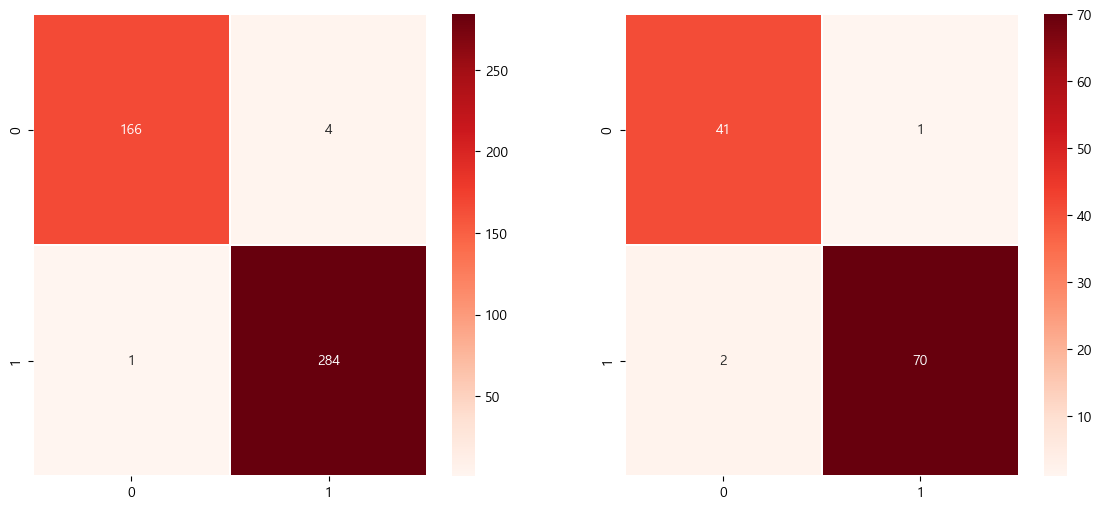

In [8]:
plt.figure(figsize=(14, 6))
c=confusion_matrix(y_train, train_pred)
plt.subplot(1,2,1)
sb.heatmap( c, 
           annot=True, 
           fmt='d',
           linewidths=0.2, 
           cmap='Reds',
           )


c=confusion_matrix(y_test, test_pred)
plt.subplot(1,2,2)
sb.heatmap( c, 
           annot=True, 
           fmt='d',
           linewidths=0.2, 
           cmap='Reds',
           )

print("train f1 :", f1_score(y_train, train_pred, average="macro"))
print("test f1 :", f1_score(y_test, test_pred, average="macro"))
print("train 정확도 :", accuracy_score(y_train, train_pred))
print("test 정확도 :", accuracy_score(y_test, test_pred))

In [10]:
scaled = st.transform(df.iloc[1:2, :-1])
(model.predict(scaled) > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[0]])